In [ ]:

!pip install -q kaggle
import os
os.environ['KAGGLE_USERNAME'] = "*****"
os.environ['KAGGLE_KEY'] = "*****"



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
!kaggle datasets download -d benjaminawd/new-york-times-articles-comments-2020 --unzip -p ./data

Dataset URL: https://www.kaggle.com/datasets/benjaminawd/new-york-times-articles-comments-2020
License(s): CC-BY-NC-SA-4.0
100%|█████████████████████████████████████| 1.95G/1.95G [10:54<00:00, 3.20MB/s]



In [3]:
import os
print(os.listdir("./data"))

['nyt-comments-2020.csv', 'nyt-comments-part4.csv', 'nyt-comments-part5.csv', 'test.csv', 'nyt-comments-part7.csv', 'nyt-comments-part6.csv', 'nyt-comments-part2.csv', 'nyt-comments-part3.csv', 'nyt-comments-part1.csv', 'nyt-comments-part0.csv', 'nyt-comments-part8.csv', 'nyt-comments-part9.csv', 'train.csv', 'nyt-articles-2020.csv']


In [3]:
!pip install pandas
import pandas as pd
articles = pd.read_csv("./data/nyt-articles-2020.csv", nrows=5)
print(articles.columns.tolist())
articles.head()


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
['newsdesk', 'section', 'subsection', 'material', 'headline', 'abstract', 'keywords', 'word_count', 'pub_date', 'n_comments', 'uniqueID']


,newsdesk,section,subsection,material,headline,abstract,keywords,word_count,pub_date,n_comments,uniqueID
0,Editorial,Opinion,NaN,Editorial,Protect Veterans From Fraud,Congress could do much more to protect America...,"['Veterans', 'For-Profit Schools', 'Financial ...",680,2020-01-01 00:18:54+00:00,186,nyt://article/69a7090b-9f36-569e-b5ab-b0ba5bb3...
1,Games,Crosswords & Games,NaN,News,‘It’s Green and Slimy’,Christina Iverson and Jeff Chen ring in the Ne...,['Crossword Puzzles'],931,2020-01-01 03:00:10+00:00,257,nyt://article/9edddb54-0aa3-5835-a833-d311a76f...
2,Science,Science,NaN,News,Meteor Showers in 2020 That Will Light Up Nigh...,"All year long, Earth passes through streams of...","['Meteors and Meteorites', 'Space and Astronom...",1057,2020-01-01 05:00:08+00:00,6,nyt://article/04bc90f0-b20b-511c-b5bb-3ce13194...
3,Science,Science,NaN,Interactive Feature,Sync your calendar with the solar system,"Never miss an eclipse, a meteor shower, a rock...","['Space and Astronomy', 'Moon', 'Eclipses', 'S...",0,2020-01-01 05:00:12+00:00,2,nyt://interactive/5b58d876-9351-50af-9b41-a312...
4,Science,Science,NaN,News,"Rocket Launches, Trips to Mars and More 2020 S...",A year full of highs and lows in space just en...,"['Space and Astronomy', 'Private Spaceflight',...",1156,2020-01-01 05:02:38+00:00,25,nyt://article/bd8647b3-8ec6-50aa-95cf-2b81ed12...


In [1]:
!pip install numpy
import numpy as np

SUBSAMPLE   = True      # True = fast Colab run; False = full dataset
SAMPLE_SIZE = 5000      # articles to keep when subsampling
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [4]:
# adjust the filename and column names to match Step A output
COLS = ["headline", "abstract", "section", "pub_date"]   # confirm these exist

df = pd.read_csv("./data/nyt-articles-2020.csv", usecols=lambda c: c in COLS)

# build the text unit we'll cluster on
df["text"] = (df["headline"].fillna("") + ". " + df["abstract"].fillna("")).str.strip()
df = df[df["text"].str.len() > 10].reset_index(drop=True)   # drop near-empty docs

if SUBSAMPLE:
    df = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=RANDOM_SEED).reset_index(drop=True)

print(f"Loaded {len(df)} articles")
df.head()

Loaded 5000 articles


,section,headline,abstract,pub_date,text
0,Arts,Picasso Mural Torn From Building After Years o...,To the outrage of preservationists and art-wor...,2020-07-30 15:14:25+00:00,Picasso Mural Torn From Building After Years o...
1,New York,"Nail Salons, Lifeline for Immigrants, Have Los...","New York City nail salons reopened in July, bu...",2020-11-23 10:00:21+00:00,"Nail Salons, Lifeline for Immigrants, Have Los..."
2,Podcasts,Kicked Out of China,As the coronavirus escalated to a worldwide cr...,2020-04-16 09:59:52+00:00,Kicked Out of China. As the coronavirus escala...
3,Arts,"Tiwa Savage, Queen of Afrobeats, Makes a New S...",A Nigerian superstar is courting an audience i...,2020-09-07 17:15:16+00:00,"Tiwa Savage, Queen of Afrobeats, Makes a New S..."
4,Sports,2020: The Year in Sports When Everybody Lost,The state of Wisconsin is a microcosm of the f...,2020-12-14 03:05:20+00:00,2020: The Year in Sports When Everybody Lost. ...


In [5]:
import re

STOPWORDS = {
    "the","a","an","and","or","but","to","of","in","on","for","is","are","was",
    "were","be","been","with","that","this","it","its","as","at","by","from",
    "has","have","had","he","she","they","we","you","i","his","her","their",
    "not","no","do","does","did","will","would","can","could","about","after",
    "over","new","says","said"
}
STOPWORDS_FULL = set("""a about above after again against all am an and any are aren't as at
be because been before being below between both but by can't cannot could couldn't did
didn't do does doesn't doing don't down during each few for from further had hadn't has
hasn't have haven't having he he'd he'll he's her here here's hers herself him himself his
how how's i i'd i'll i'm i've if in into is isn't it it's its itself let's me more most
mustn't my myself no nor not of off on once only or other ought our ours ourselves out over
own same shan't she she'd she'll she's should shouldn't so some such than that that's the
their theirs them themselves then there there's these they they'd they'll they're they've
this those through to too under until up very was wasn't we we'd we'll we're we've were
weren't what what's when when's where where's which while who who's whom why why's with
won't would wouldn't you you'd you'll you're you've your yours yourself yourselves
say says said new now one will can may year years time first""".split())

def preprocess(text):
    text = text.lower()                     # 1. normalize case
    text = re.sub(r"[^a-z\s]", " ", text)   # 2. strip punctuation, digits, symbols
    tokens = text.split()                   # 3. tokenize on whitespace
    tokens = [t for t in tokens             # 4. remove stopwords + very short words
              if t not in STOPWORDS_FULL and len(t) > 2]
    return tokens

df["tokens"] = df["text"].map(preprocess)

# drop articles that became empty after cleaning
df = df[df["tokens"].map(len) > 0].reset_index(drop=True)

In [6]:
print(f"{len(df)} articles after preprocessing")
print("Example:", df["tokens"].iloc[0][:15])

5000 articles after preprocessing
Example: ['picasso', 'mural', 'torn', 'building', 'dispute', 'outrage', 'preservationists', 'art', 'world', 'figures', 'work', 'removed', 'storage', 'thursday', 'side']


In [7]:
from collections import Counter

# --- 1. Document frequency: in how many articles does each word appear? ---
doc_freq = Counter()
for tokens in df["tokens"]:
    doc_freq.update(set(tokens))          # set() => count each word once per article

N = len(df)

# --- 2. Build a capped vocabulary ---
# keep words that are neither too rare (noise) nor too common (no signal)
MIN_DF = 5                                 # appear in >= 5 articles
MAX_DF = 0.5 * N                           # appear in <= 50% of articles
VOCAB_SIZE = 3000

candidates = [w for w, c in doc_freq.items() if MIN_DF <= c <= MAX_DF]
candidates.sort(key=lambda w: doc_freq[w], reverse=True)
vocab = candidates[:VOCAB_SIZE]
word_index = {w: i for i, w in enumerate(vocab)}

# --- 3. Precompute IDF for each vocabulary word ---
idf = np.array([np.log(N / doc_freq[w]) for w in vocab])

# --- 4. Build the TF-IDF vector for one article ---
def tfidf_vector(tokens):
    vec = np.zeros(len(vocab))
    counts = Counter(tokens)
    total = len(tokens)
    for word, count in counts.items():
        j = word_index.get(word)
        if j is not None:
            tf = count / total            # term frequency, length-normalized
            vec[j] = tf * idf[j]          # TF-IDF weight
    norm = np.linalg.norm(vec)
    return vec / norm if norm > 0 else vec  # L2-normalize => cosine-ready

# --- 5. Stack into the data matrix ---
X = np.vstack([tfidf_vector(t) for t in df["tokens"]])
print("Data matrix shape:", X.shape)        # (n_articles, vocab_size)

Data matrix shape: (5000, 3000)


In [13]:
def kmeans(X, k, max_iter=100, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    n = X.shape[0]

    # --- Initialization: furthest-point heuristic (textbook 7.3.2) ---
    first = rng.integers(n)
    centroid_idx = [first]
    # min distance from each point to the set of chosen centroids
    min_dist = np.linalg.norm(X - X[first], axis=1)
    while len(centroid_idx) < k:
        nxt = np.argmax(min_dist)              # point furthest from all chosen
        centroid_idx.append(nxt)
        d = np.linalg.norm(X - X[nxt], axis=1)
        min_dist = np.minimum(min_dist, d)     # keep running minimum
    centroids = X[centroid_idx].copy()

    # --- Lloyd iteration: assign, then update (textbook Fig. 7.7) ---
    for iteration in range(max_iter):
        # assignment step: nearest centroid for every point
        dists = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
        labels = dists.argmin(axis=1)

        # update step: centroid = mean of its assigned points
        new_centroids = np.array([
            X[labels == j].mean(axis=0) if np.any(labels == j) else centroids[j]
            for j in range(k)
        ])

        # convergence check
        if np.allclose(new_centroids, centroids):
            break
        centroids = new_centroids

    return labels, centroids, iteration + 1

labels, centroids, n_iter = kmeans(X, 10)
print(f"Converged in {n_iter} iterations")
print("Cluster sizes:", np.bincount(labels))

Converged in 20 iterations
Cluster sizes: [3040  330   67  130  166  170  633   80  312   72]


n=1000: 4.5s
n=2000: 14.7s
n=5000: 37.8s


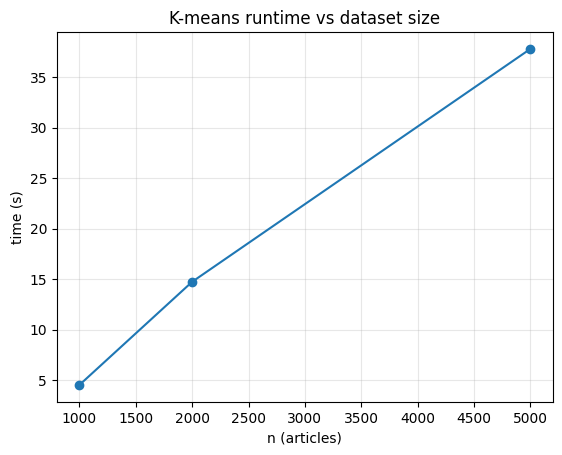

In [19]:
import time
sizes = [1000, 2000, 5000]
times = []
for n in sizes:
    Xn = X[:n]
    t0 = time.time()
    kmeans(Xn, k=10)
    times.append(time.time() - t0)
    print(f"n={n}: {times[-1]:.1f}s")

import matplotlib.pyplot as plt
plt.plot(sizes, times, "o-")
plt.xlabel("n (articles)"); plt.ylabel("time (s)")
plt.title("K-means runtime vs dataset size")
plt.grid(alpha=0.3); plt.show()

In [14]:
def wcss(X, labels, centroids):
    total = 0.0
    for j in range(len(centroids)):
        pts = X[labels == j]
        if len(pts) > 0:
            total += np.sum((pts - centroids[j]) ** 2)
    return total

In [15]:
k_values = [2, 3, 4, 5, 6, 8, 10, 12, 15]
scores = []
for k in k_values:
    lab, cen, _ = kmeans(X, k=k)
    scores.append(wcss(X, lab, cen))
    print(f"k={k:2d}  WCSS={scores[-1]:.4f}")

print("len(k_values) =", len(k_values), " len(scores) =", len(scores))  # must match

k= 2  WCSS=4950.6358
k= 3  WCSS=4942.1108
k= 4  WCSS=4937.0955
k= 5  WCSS=4929.2068
k= 6  WCSS=4913.2114
k= 8  WCSS=4900.9921
k=10  WCSS=4895.4254
k=12  WCSS=4876.4846
k=15  WCSS=4864.1387
len(k_values) = 9  len(scores) = 9


In [24]:
!pip install matplotlib


Python(74293) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


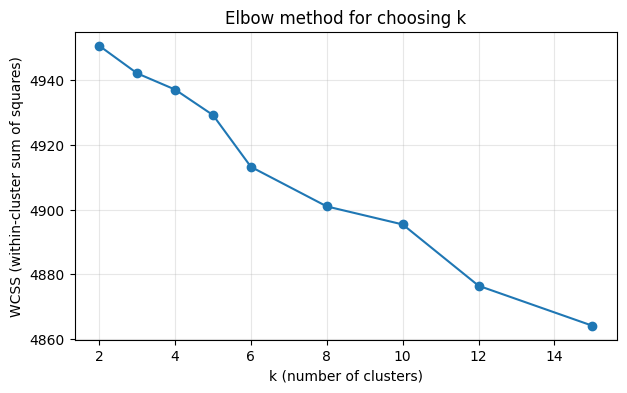

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
plt.plot(k_values, scores, "o-")
plt.xlabel("k (number of clusters)")
plt.ylabel("WCSS (within-cluster sum of squares)")
plt.title("Elbow method for choosing k")
plt.grid(alpha=0.3)
plt.show()

In [17]:
def top_terms(centroids, vocab, n=10):
    for j, c in enumerate(centroids):
        top = np.argsort(c)[::-1][:n]
        words = [vocab[i] for i in top]
        print(f"Cluster {j} ({np.sum(labels==j)} articles): {', '.join(words)}")

top_terms(centroids, vocab)

Cluster 0 (3040 articles): trump, president, biden, pandemic, like, people, many, home, american, make
Cluster 1 (330 articles): york, city, police, pandemic, times, diary, mayor, reader, yorkers, metropolitan
Cluster 2 (67 articles): court, supreme, justices, trump, care, ruling, act, hear, justice, ginsburg
Cluster 3 (130 articles): case, iran, killing, attorney, general, trump, barr, suleimani, president, justice
Cluster 4 (166 articles): life, real, week, last, puzzles, stumped, heck, solvers, entries, look
Cluster 5 (170 articles): moment, books, offer, finding, comfort, escape, writers, world, read, readers
Cluster 6 (633 articles): coronavirus, virus, pandemic, vaccine, cases, outbreak, china, health, covid, states
Cluster 7 (80 articles): favorite, share, moments, performances, times, readers, back, asked, fall, games
Cluster 8 (312 articles): back, white, house, war, trump, president, get, home, old, coronavirus
Cluster 9 (72 articles): homes, sale, bedroom, house, properties,

In [18]:
df["cluster"] = labels
crosstab = pd.crosstab(df["cluster"], df["section"])
print(crosstab)

# dominant section per cluster + how pure that cluster is
for j in range(len(centroids)):
    row = crosstab.loc[j]
    dominant = row.idxmax()
    purity = row.max() / row.sum()
    print(f"Cluster {j}: mostly '{dominant}' ({purity:.0%} pure)")

section  Admin  Arts  At Home  Automobiles  Books  Business Day  Climate  \
cluster                                                                    
0            1   221        1            1     68           154       36   
1            0    21        0            0      4             8        1   
2            0     0        0            0      2             0        0   
3            0     5        0            0      1             4        3   
4            0    13        0            0     13             6        1   
5            0    28        1            0     27             5        1   
6            0    18        0            0      0            64        4   
7            0     9        0            0      1             4        0   
8            0    18        0            0      9            15        4   
9            0     0        0            0      0             0        0   

section  Crosswords & Games  Education  Fashion & Style  ...  The Weekly  \
cluster    